## 0. Preprocessing for the OPLS data

loading scans: [51218 51219]


/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


scan 51218: monitor_3 average = 3.646537087758402
no chamber data
sum frames of each scan
loading done
scan 51218: qxy0 = 0.04061061973771442 /A, sample height = -0.9753980153572996
scan 51219: monitor_3 average = 3.6492434358596997
no chamber data
sum frames of each scan
loading done
scan 51219: qxy0 = 0.04061061973771419 /A, sample height = -1.975403952857306
saving 1D GIXOS .txt files under: /Users/xiaogangyang/data/opls-pxrr/
saved GIXOS 1D: /Users/xiaogangyang/data/opls-pxrr/gixos2/PFOA_0p2mM_chit_2gL_pH6_run2_gixos-id51218.txt
saved GIXOS 1D: /Users/xiaogangyang/data/opls-pxrr/gixos2/PFOA_0p2mM_chit_2gL_pH6_run2_gixos_bkg-id51219.txt
config written: /Users/xiaogangyang/data/opls-pxrr/gixos-process_config_1d_51218.yaml


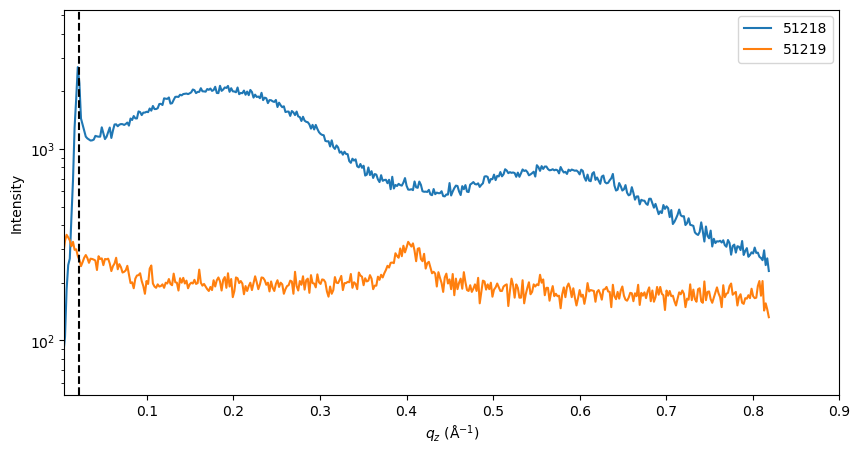

In [1]:
from pxrr.nsls2_opls_input import process_opls

opls, metadata_file = process_opls(
    start_scan=51218,
    n_scan=2,
    path='/Users/xiaogangyang/data/opls-pxrr/',
    metadata_output='/Users/xiaogangyang/data/opls-pxrr/'
)


# Optional overrides example:
# opls2, meta2 = process_opls(start_scan=..., n_scan=..., path=..., sample_name='my_sample', kappa=5, tension=0.072, plot=True)

In [2]:
from pxrr.data_io import load_metadata

meta = load_metadata(metadata_file)
print('sample from yaml:', meta['measurements']['sample'])
print('kappa from yaml:', meta['sample_params']['kappa'])

sample from yaml: PFOA_0p2mM_chit_2gL_pH6_run2_gixos
kappa from yaml: 5.0


## Pseudo-XRR from 1D GIXOS linecuts (OPLS / NSLS-II 12ID)

Step-by-step workflow analogous to `pXRR_step2.ipynb`, using the new pxrr
(extended capillary wave model) API and the OPLS metadata configuration
(`opls_1d/gixos-process_config_1d.yaml`).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import pi

from pxrr.eCWM import *
from pxrr.data_io import (
    load_gixos_from_meta,
    save_metadata_yaml,
    export_gixos_nxs,
    load_gixos_nxs,
    export_orso,
)
from pxrr.gixos import (
    binning_GIXOS_tt,
    remove_negative_2theta,
    GIXOS_th2q,
    GIXOS_background_corr,
    GIXOS_correct,
    GIXOS_qxy_dependence,
    GIXOS2R,
)
from pxrr.helpers import make_filename


### 2. Load configuration and data

Load sample and chamber-background GIXOS data directly from the OPLS YAML
configuration. All metadata is attached to the GIXOS dictionaries under
`["metadata"]`; the YAML file is no longer needed after this point.

In [4]:
# metadata_file was produced by cell 2 (opls.save_metadata_yaml)
GIXOSdata, GIXOSbkg = load_gixos_from_meta(metadata_file)

indicator
load 1d gixos cuts from NSLS-II/12ID
1d gixos is loaded
1d gixos is loaded


### 3. Corrections

- vertical binning in `tt` (beta)
- remove negative 2theta rows
- convert angular axes to Q

constant bulk background: average above Qz lower bound


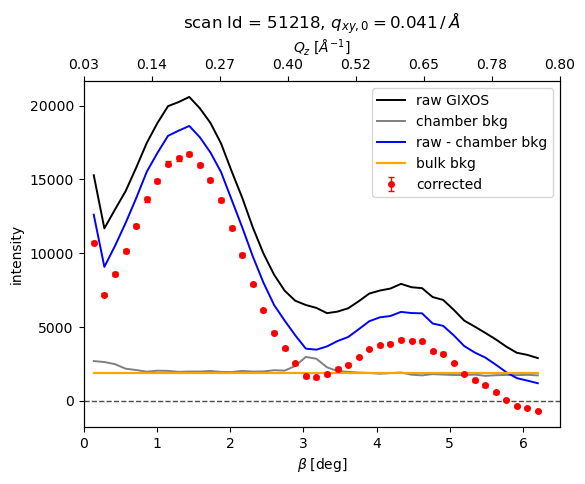

In [5]:
# Corrections (step 3) + background subtraction (step 4) in one call
GIXOS_ana = GIXOS_correct(
    GIXOSdata,
    GIXOSbkg,
    bulkbkg_mode=0,
    bulkbkg_const_mode=1,
    bulkbkg_const_qz_lb=0.7,
    plot=True,
)

# --- Old way (backup) ---
# GIXOSdata = binning_GIXOS_tt(GIXOSdata)
# GIXOSbkg  = binning_GIXOS_tt(GIXOSbkg)
#
# GIXOSdata = remove_negative_2theta(GIXOSdata)
# GIXOSbkg  = remove_negative_2theta(GIXOSbkg)
#
# GIXOSdata_q = GIXOS_th2q(GIXOSdata)
# GIXOSbkg_q  = GIXOS_th2q(GIXOSbkg)


### 4. Background subtraction

Subtract chamber background and a constant bulk background determined from
the high-Qz average (`bulkbkg_mode=0`, `bulkbkg_const_mode=1`).

constant bulk background: average above Qz lower bound


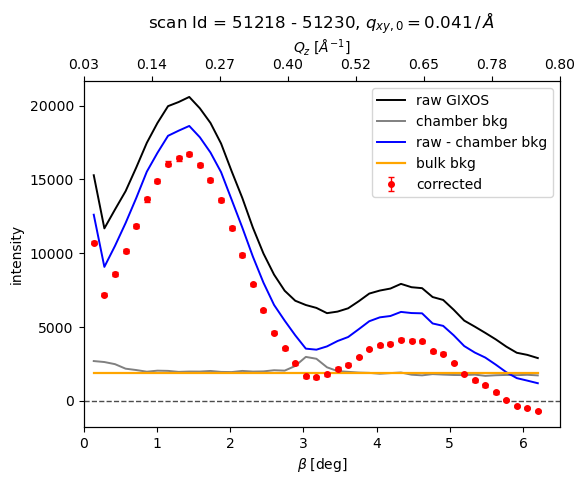

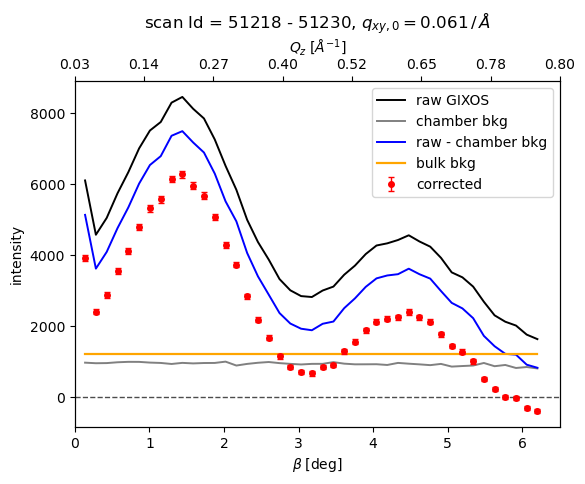

In [ ]:
# --- Old way (backup, now handled by GIXOS_correct in the previous cell) ---
# GIXOS_ana = GIXOS_background_corr(
#     GIXOSdata_q,
#     GIXOSbkg_q,
#     bulkbkg_mode=0,
#     bulkbkg_const_mode=1,
#     bulkbkg_const_qz_lb=0.7,
#     plot=True,
# )


### 5. Save / reload corrected GIXOS (NeXus HDF5)

Store the corrected GIXOS dictionary (data + metadata) so the analysis can
be resumed later. The reloaded copy `GIXOS_back` is only shown for demo.

In [6]:
outgixosfile = make_filename(GIXOS_ana["metadata"], suffix="gixos.h5")
export_gixos_nxs(GIXOS_ana, outgixosfile)

GIXOS_back = load_gixos_nxs(outgixosfile)
print("reloaded keys:", list(GIXOS_back.keys()))

reloaded keys: ['HWpx_h', 'HWpx_v', 'HWtt', 'HWtth', 'Intensity', 'Q', 'Qxy', 'Qz', 'bulkbkg', 'error', 'metadata', 'tt', 'tth']


### 6. Qxy dependence fit

Fit the bending modulus `kappa` from the Qxy dependence of the diffuse
intensity at the Qz values listed in `metadata['dependency']['qz_selected']`.
Subsequent operations write back into `GIXOS_ana` (shared dict).

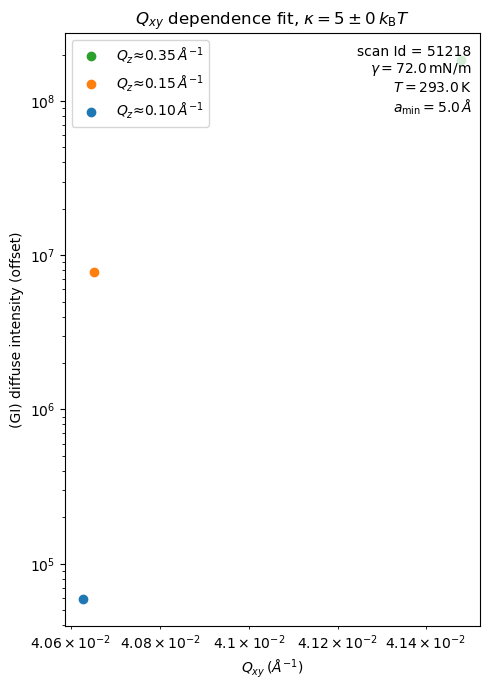

In [12]:
_, qxy_dependence_fit = GIXOS_qxy_dependence(
    GIXOS_ana,
    GIXOS_ana["metadata"]["dependency"]["qz_selected"],
    row_window=2,
    fit_kappa=True,
)

### 7. Convert GIXOS to pseudo-reflectivity and structure factor

Apply the eCWM roughness factors at the selected `qxy0` positions to obtain
`R(Qz)`, `|Phi(Qz)|^2`, and the specular roughness factor `Psi_R(Qz)`.

No footprint broadending calculation. For calculation: please set footprint_effect = True and provide the footprint [mm], detector distance Ddet [mm], incident angle alpha [deg] and energy [eV] in metadata field
start calculating the specular roughness factor
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset phi left and right
bkg by offset 

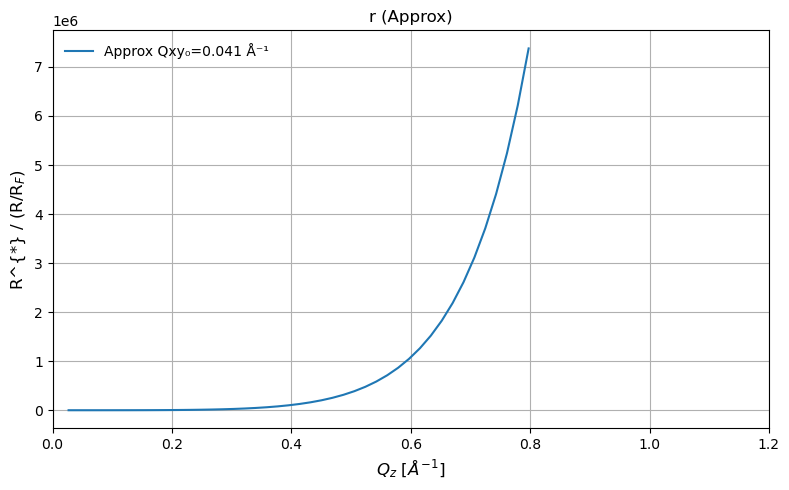

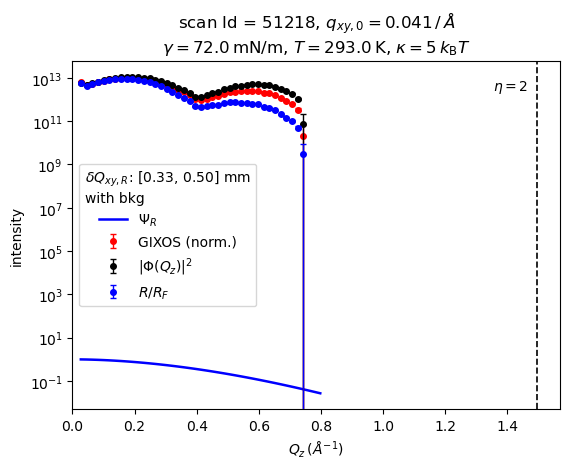

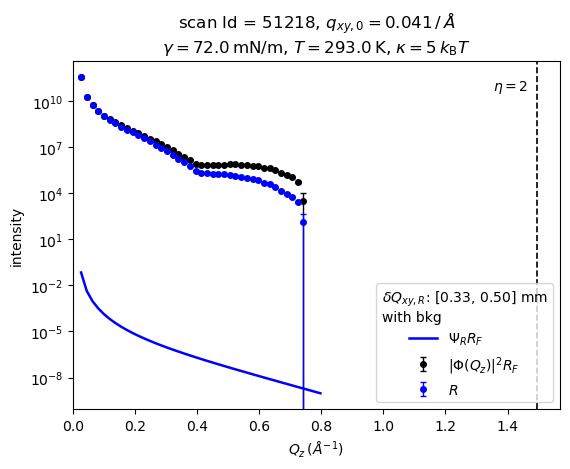

In [8]:
_ = GIXOS2R(
    GIXOS_ana,
    transmission_corr=True,
    footprint_effect=False,
    use_approx=True,
)

### 8. Export updated configuration YAML

Save the metadata back to YAML (in the same structure as the input config),
now including the fitted bending modulus `kappa`.

In [9]:
configfilename = make_filename(GIXOS_ana["metadata"], suffix="cfg.yaml")
save_metadata_yaml(GIXOS_ana["metadata"], configfilename)
print("config written:", configfilename)

config written: ./testing_data/output/opls_full/PFOA_0p2mM_chit_2gL_pH6_run2_gixos_51218_cfg.yaml


### 9. Export ORSO files

- `refl`  : pseudo-reflectivity R(Qz)
- `SF`    : structure factor |Phi(Qz)|^2
- `GIXOS` : background-corrected GIXOS (I0 * R*)

In [10]:
_ = export_orso(GIXOS_ana, which="refl")
_ = export_orso(GIXOS_ana, which="SF")
_ = export_orso(GIXOS_ana, which="GIXOS")

/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/orsopy/fileio/base.py:134: ORSOSchemaWarning: No suitable conversion found for start_date, <class 'datetime.datetime'> with value , setting attribute with raw value from ORSO file
  warnings.warn(
/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/orsopy/fileio/base.py:134: ORSOSchemaWarning: No suitable conversion found for start_date, <class 'datetime.datetime'> with value , setting attribute with raw value from ORSO file
  warnings.warn(
/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/orsopy/fileio/base.py:134: ORSOSchemaWarning: No suitable conversion found for start_date, <class 'datetime.datetime'> with value , setting attribute with raw value from ORSO file
  warnings.warn(
